In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
titanic = sns.load_dataset('titanic')

Text(0, 0.5, 'age count')

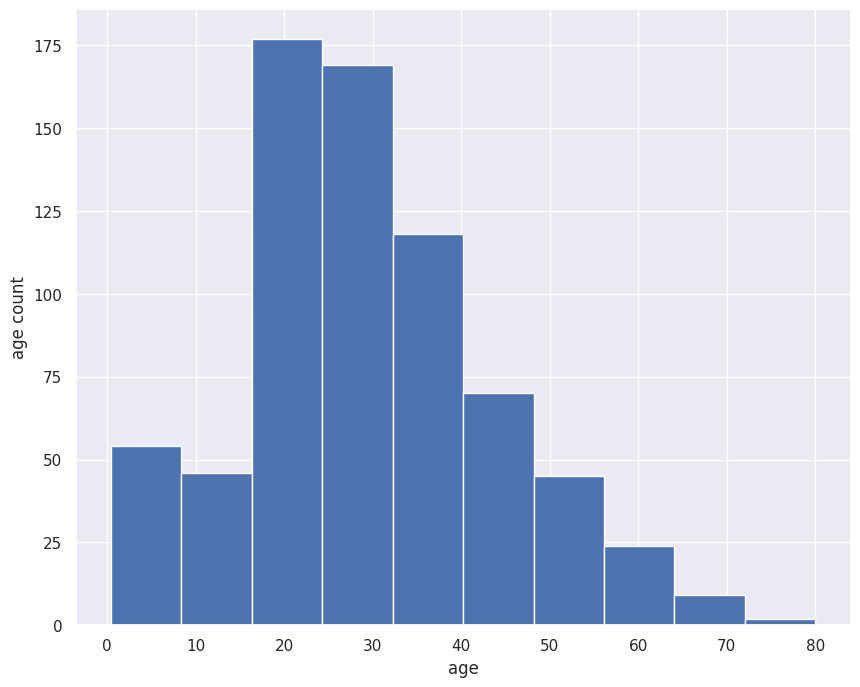

In [111]:
plt.hist(titanic['age'])
plt.xlabel('age')
plt.ylabel('age count')

Text(0, 0.5, 'count in every class')

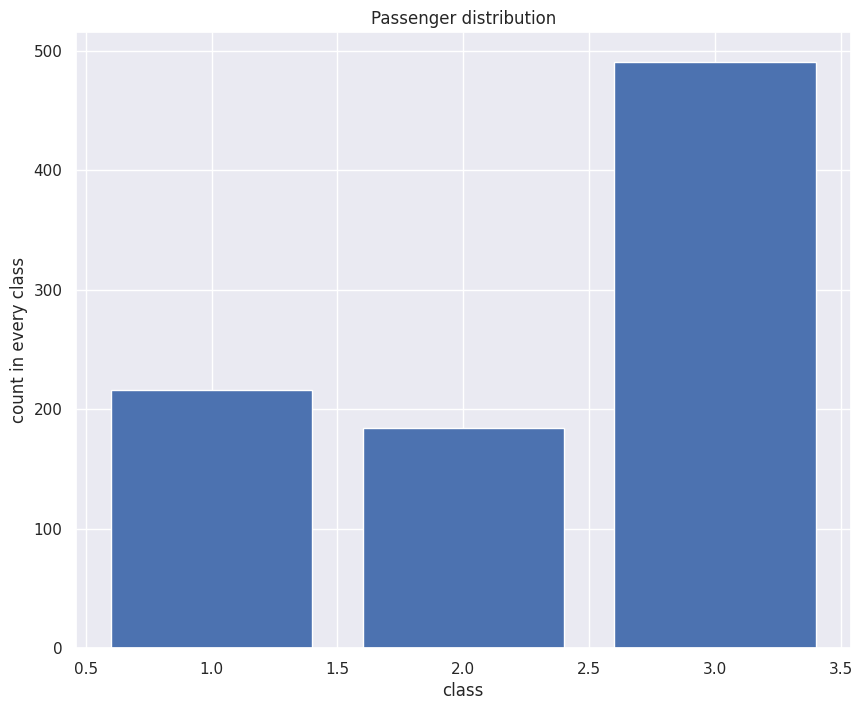

In [112]:
pclass = titanic['pclass'].value_counts()
plt.bar(pclass.index, pclass.values)
plt.title('Passenger distribution')
plt.xlabel('class')
plt.ylabel('count in every class')

Text(0, 0.5, 'fare')

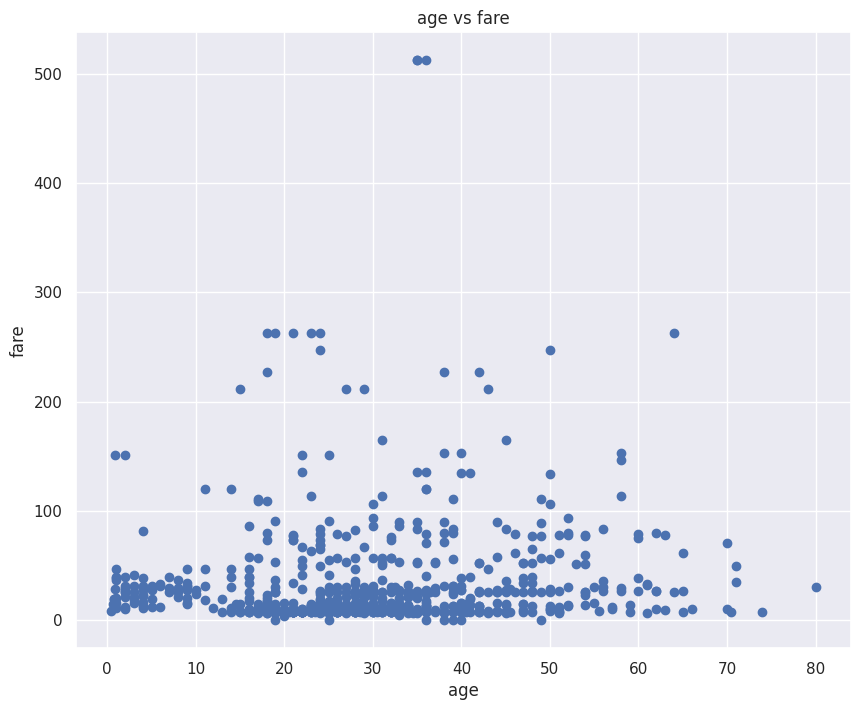

In [113]:
plt.scatter(titanic['age'], titanic['fare'])
plt.title('age vs fare')
plt.xlabel('age')
plt.ylabel('fare')

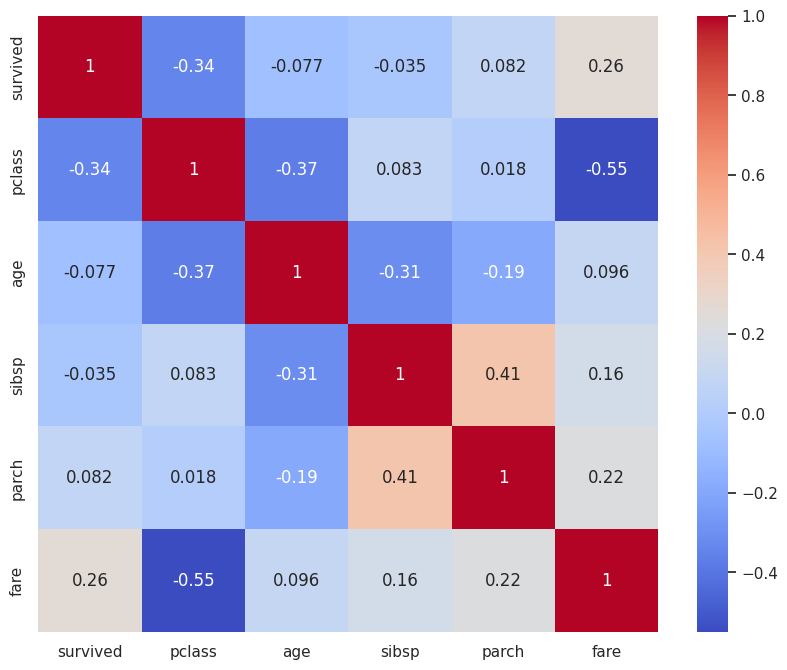

In [114]:
numeric_titanic = titanic.select_dtypes(include= ['number'])
sns.set(rc={'figure.figsize': (10,8)})
sns.heatmap(numeric_titanic.corr(), annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='pclass', ylabel='age'>

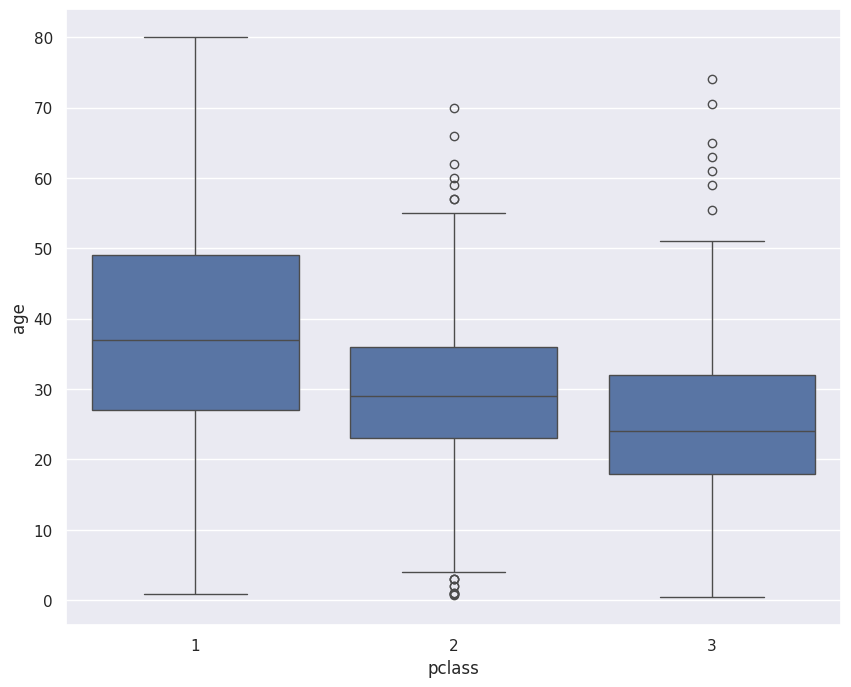

In [115]:
sns.boxplot(x=titanic['pclass'], y=titanic['age'])

<Axes: xlabel='sex', ylabel='count'>

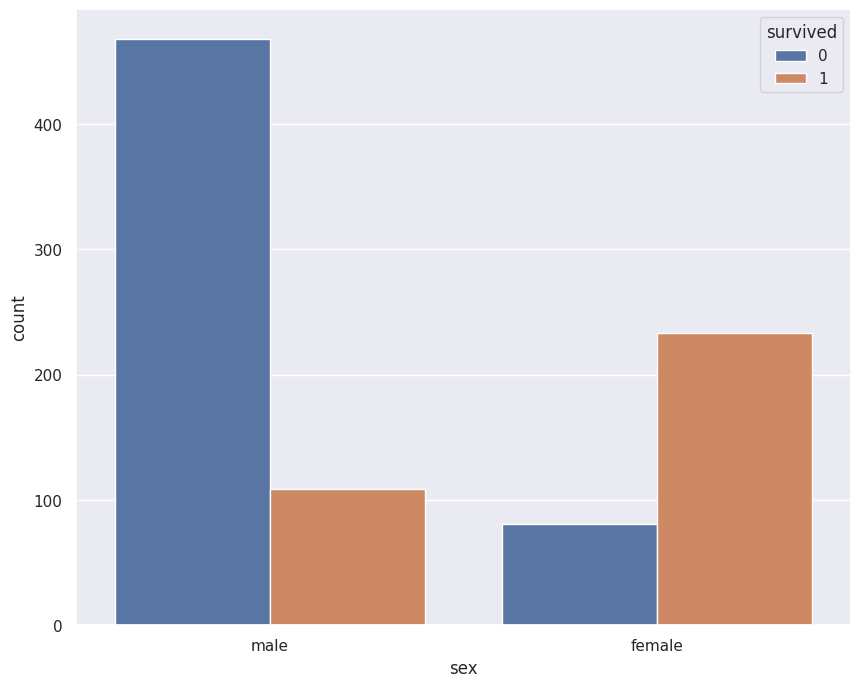

In [116]:
sns.countplot(data=titanic, x='sex', hue='survived')

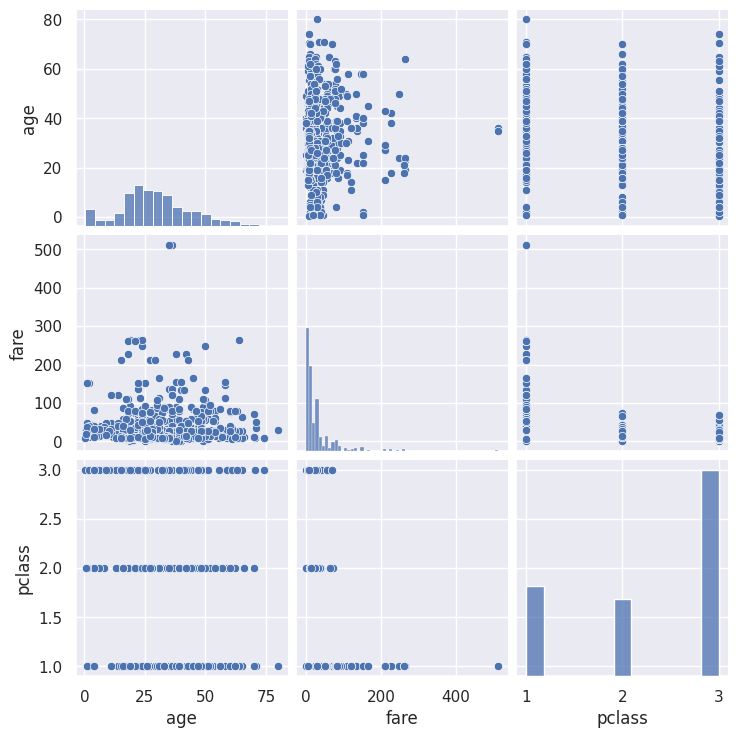

In [117]:
sns.pairplot(titanic, vars=['age', 'fare', 'pclass'] )

In [118]:
import sklearn.preprocessing
titanic['sex'] = titanic['sex'].map({'male' : 0, 'female' : 1})


In [119]:
titanic = pd.get_dummies(titanic, columns=['embarked'])
#اللي فهمتو انو لو استعملنا الmapرح يعطي واحد من الموانئ قيمة 2 
#و هاي ممكن تخلي الماشين و هي بتتعلم تفكر رقم 2 الو افصلية 
#و اللي فهمتو كمان انو هاي الحركو بتعمل 3 اعمدة جديدة و النتائج جواتهم ياترو او فولس او صفر و واحد

In [120]:
print(titanic.dtypes)

survived          int64
pclass            int64
sex               int64
age             float64
sibsp             int64
parch             int64
fare            float64
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
embarked_C         bool
embarked_Q         bool
embarked_S         bool
dtype: object


In [121]:
titanic['class']
titanic['deck']
titanic['alive']
titanic['embark_town']
titanic = titanic.drop(columns=['class', 'deck', 'alive', 'embark_town', 'who'])

In [122]:
titanic.dtypes

survived        int64
pclass          int64
sex             int64
age           float64
sibsp           int64
parch           int64
fare          float64
adult_male       bool
alone            bool
embarked_C       bool
embarked_Q       bool
embarked_S       bool
dtype: object

In [123]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler
print(titanic[['fare' , 'age']].head())
mn_scaler  = MinMaxScaler()
s_scaler = StandardScaler()
mn_titanic = titanic.copy()
mn_titanic[['fare', 'age']] = mn_scaler.fit_transform(titanic[['fare', 'age']])



      fare   age
0   7.2500  22.0
1  71.2833  38.0
2   7.9250  26.0
3  53.1000  35.0
4   8.0500  35.0


In [124]:
print(mn_titanic[['fare' , 'age']])

         fare       age
0    0.014151  0.271174
1    0.139136  0.472229
2    0.015469  0.321438
3    0.103644  0.434531
4    0.015713  0.434531
..        ...       ...
886  0.025374  0.334004
887  0.058556  0.233476
888  0.045771       NaN
889  0.058556  0.321438
890  0.015127  0.396833

[891 rows x 2 columns]


In [125]:
s_titanic = titanic.copy()
s_titanic[['fare', 'age']] = s_scaler.fit_transform(s_titanic[['fare', 'age']])
print(s_titanic[['fare', 'age']])

#الصراحة المفاهيم هاي جديدة علية فطولت لفهمتهم و مش كتير بحس حالي فاهم 
#بس اللي لاحظنو انو المن و الماكس سكيلؤ ان الستنادرد بالاشارة يعني اعطاني اشارة سالبة 
#مش كتير فاهم ليش 
#بس موضوع توحيد الارقام ضروري عشان الماشين ليرننج ما يطلع توقعات غلط 
#زي مثلا لما نوحد الوحد بالفيزياء يعني مثلا المترين لو كانو بالسانتي رح يعطيني رقم 200 
#و الكمبيوتر بس بشوف ارقام ما بفهم انو هاي وحدتها كذا و هاي وحدتها كذا

         fare       age
0   -0.502445 -0.530377
1    0.786845  0.571831
2   -0.488854 -0.254825
3    0.420730  0.365167
4   -0.486337  0.365167
..        ...       ...
886 -0.386671 -0.185937
887 -0.044381 -0.737041
888 -0.176263       NaN
889 -0.044381 -0.254825
890 -0.492378  0.158503

[891 rows x 2 columns]


In [126]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
print(titanic.head())

   survived  pclass  sex   age  sibsp  parch     fare  adult_male  alone  \
0         0       3    0  22.0      1      0   7.2500        True  False   
1         1       1    1  38.0      1      0  71.2833       False  False   
2         1       3    1  26.0      0      0   7.9250       False   True   
3         1       1    1  35.0      1      0  53.1000       False  False   
4         0       3    0  35.0      0      0   8.0500        True   True   

   embarked_C  embarked_Q  embarked_S  family_size  
0       False       False        True            2  
1        True       False       False            2  
2       False       False        True            1  
3       False       False        True            2  
4       False       False        True            1  


In [131]:
#for i in range(titanic['age'].size):
 #   if titanic.loc[i, 'age'] < 13:
  #      titanic.loc[i, 'age_group'] = "chiled"
   # elif titanic.loc[i, 'age'] >= 13 and titanic.loc[i, 'age'] <19 :
    #    titanic.loc[i, 'age_group'] = "teenager"
    #elif titanic.loc[i ,'age'] >=19 and titanic.loc[i, 'age'] <59:
     #   titanic.loc[i, 'age_group'] = 'adult'
    #elif titanic.loc[i ,'age'] >=60 and titanic.loc[i, 'age'] <100:
     #   titanic.loc[i, 'age_group'] = 'old'
#print(titanic.head(10))

titanic['age_group'] = pd.cut(titanic['age'] , bins= [0,12,19,59,100], labels=['Child', 'Teenager', 'Adult', 'old'])
print(titanic['age_group'])


0         Adult
1         Adult
2         Adult
3         Adult
4         Adult
         ...   
886       Adult
887    Teenager
888         NaN
889       Adult
890       Adult
Name: age_group, Length: 891, dtype: category
Categories (4, object): ['Child' < 'Teenager' < 'Adult' < 'old']


In [ ]:
titanic['fare_per_person'] = titanic['fare'] / titanic['family_size']
print(titanic[['fare_per_person', 'fare']])
#اه اعطى منطقية اكبر 
#عشان سعر التذكرة صارت للفرد مو كل عيلة كم دفعت 

     fare_per_person     fare
0            3.62500   7.2500
1           35.64165  71.2833
2            7.92500   7.9250
3           26.55000  53.1000
4            8.05000   8.0500
..               ...      ...
886         13.00000  13.0000
887         30.00000  30.0000
888          5.86250  23.4500
889         30.00000  30.0000
890          7.75000   7.7500

[891 rows x 2 columns]
